In [ ]:
from langgraph.graph import START,END,StateGraph
from typing import  TypedDict
from langchain_ollama import ChatOllama

c:\projects\Langraph\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [35]:
class LLMState(TypedDict):
   question:str
   output:str


In [36]:
llm=ChatOllama(model='gemma4:31b-cloud' )

In [37]:
graph=StateGraph(LLMState)

In [38]:
from langchain_core.messages import HumanMessage, SystemMessage

def llmqa(state:LLMState)->LLMState:

    response = llm.invoke([
        SystemMessage(content="You are a football expert."),
        HumanMessage(content="Who is Cristiano Ronaldo?")
    ])
    state['output']=response.content
    return state

## node and edges

In [39]:
graph.add_node('llmqa',llmqa)

graph.add_edge(START,'llmqa')
graph.add_edge('llmqa',END)

workflow=graph.compile()

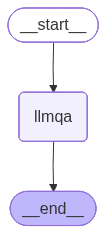

In [40]:
workflow

In [41]:
final_state=workflow.invoke({'question':"how is cristiano ronaldo"})

In [45]:
print(final_state['output'])

**Cristiano Ronaldo** is widely regarded as one of the greatest football (soccer) players of all time. A Portuguese international, he is known for his extraordinary athleticism, goal-scoring instinct, and relentless work ethic.

Here is a detailed breakdown of who he is and why he is significant:

### 1. Professional Career
Ronaldo has played for some of the biggest clubs in the world:
*   **Sporting CP (Portugal):** Where he began his professional career as a teenager.
*   **Manchester United (England):** Where he rose to global stardom under Sir Alex Ferguson, winning his first Ballon d'Or and Champions League title.
*   **Real Madrid (Spain):** Where he spent the peak of his career (2009–2018). He became the club's all-time leading goalscorer and won four Champions League titles.
*   **Juventus (Italy):** Where he continued his scoring dominance and won multiple Serie A titles.
*   **Al Nassr (Saudi Arabia):** His current club, where he has helped spark a massive surge of global int